In [2]:
import pandas as pd

llm_new_res = pd.read_csv("llm_new_res_v3.csv")
dblp_similarity = llm_new_res["dblp_title_similarity"]
llm_similarity = llm_new_res["similarity_correct"]

# Take the max per row, safely handling NaN values.
llm_similarity = pd.concat([llm_similarity, dblp_similarity], axis=1).max(axis=1, skipna=True)

papers_similarity = pd.read_csv("similarity_values_papers.csv")
print(len(llm_similarity))

C:\Users\20532\AppData\Local\Temp\ipykernel_102680\2324075835.py:3: DtypeWarning: Columns (0,6,8,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  llm_new_res = pd.read_csv("llm_new_res_v3.csv")


331809


Plot saved to llm_papers_similarity_ecdf.pdf


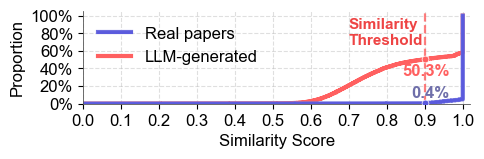

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mtick
import matplotlib.patheffects as pe

def plot_cdf_seaborn_multiple(series_dict, output_path=None):
    """
    使用 Seaborn 绘制多条经验累积分布函数 (ECDF) 折线图。
    采用学术风格配色方案。
    series_dict: {label: values}
    """
    # Academic style configuration (学术风格配置)
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Arial'],
        'axes.facecolor': '#FAFAFA',
        'figure.facecolor': 'white',
        'mathtext.fontset': 'stixsans',
        'axes.edgecolor': '#333333',
        'axes.linewidth': 0.8,
        'xtick.direction': 'out',
        'ytick.direction': 'out',
        'grid.linestyle': '--',
        'grid.alpha': 0.4,
    })
    # 过滤空数据
    cleaned_series = {}
    for label, values in series_dict.items():
        if values is None:
            continue
        if hasattr(values, "empty") and values.empty:
            continue
        clean_values = values.dropna() if hasattr(values, "dropna") else values
        if isinstance(clean_values, pd.DataFrame):
            clean_values = clean_values.iloc[:, 0]  # Assume first column if DataFrame
        if len(clean_values) == 0:
            continue
        cleaned_series[label] = clean_values

    if not cleaned_series:
        print("No values to plot")
        return

    # Slightly larger figure for better readability
    fig, ax = plt.subplots(figsize=(5, 1.2))

    # Academic color palette (与论文一致的配色)
    academic_colors = {
        'LLM-generated': '#FF6060',   # Orange-red (Hallucinated style)
        'Real papers': '#5A5ADD',      # Teal blue (Valid style)
    }

    # 绘制 ECDF (Plotting with Seaborn)
    for label, clean_values in cleaned_series.items():
        color = academic_colors.get(label, '#555555')
        sns.ecdfplot(data=clean_values, ax=ax, color=color, linewidth=2, label=label)

    # 为 ECDF 线条添加黑色描边
    for line in list(ax.get_lines())[:len(cleaned_series)]:
        stroke_effect = [pe.Stroke(linewidth=3, foreground='#FF6060' if line.get_color() == '#FF6060' else '#6F6FDE'), pe.Normal()]
        line.set_path_effects(stroke_effect)

    # 在 0.9 处画垂直线，标注 similarity threshold
    x_thresh = 0.9
    ax.axvline(x=x_thresh, color='#FF6060', linestyle='--', linewidth=1.6, alpha=0.8)
    ax.text(x_thresh + -0.20, 0.975, 'Similarity\nThreshold', fontweight='bold',fontsize=11, va='top', color='#EE4444')

    # 在阈值处标注两条线各自的百分比（累积比例）
    for label, clean_values in cleaned_series.items():
        y_ref = float(np.mean(clean_values < x_thresh))
        color = academic_colors.get(label, '#555555')
        ax.scatter([x_thresh], [y_ref], color=color, s=24, zorder=5, edgecolor='white', linewidth=0.5)
        ax.annotate(f"{y_ref * 100:.1f}%", (x_thresh, y_ref), 
                    textcoords="offset points", xytext=(-16.5, -12) if label == "LLM-generated" else (-10, 4),
                    color='#6F6FAA' if label == "Real papers" else '#FF6060', fontsize=12, fontweight='bold', ha='left')

    # 坐标轴设置 (Axis Configuration) - 更密刻度、更大字体
    ax.set_xlim(0.0, 1.02)
    ax.set_ylim(0.0, 1.05)
    ax.set_xticks(np.arange(0, 1.05, 0.1))
    ax.set_yticks(np.arange(0, 1.05, 0.2))
    ax.set_xlabel("Similarity Score", fontsize=12)
    ax.set_ylabel("Proportion", fontsize=12)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='both', labelsize=12)

    # Spine styling (隐藏顶部和右侧边框)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#555555')
    ax.spines['left'].set_linewidth(0.6)
    ax.spines['bottom'].set_color('#555555')
    ax.spines['bottom'].set_linewidth(0.6)

    # Grid below plot elements
    ax.set_axisbelow(True)
    ax.grid(True, which='major', linestyle='--', alpha=0.4)
    ax.patch.set_facecolor('#FFFFFF')
    ax.margins(x=0.01)

    handles, labels = ax.get_legend_handles_labels()
    order = [1, 0]  # 例如把 "Real papers" 放前面
    ax.legend([handles[i] for i in order],
            [labels[i] for i in order],
            frameon=False, loc='upper left', fontsize=12,
            facecolor='none', fancybox=False)

    if output_path:
        try:
            fig.savefig(output_path, dpi=300, bbox_inches='tight')
            print(f"Plot saved to {output_path}")
        except Exception as e:
            print(f"Could not save plot: {e}")


plot_cdf_seaborn_multiple({
    "LLM-generated": llm_similarity,
    "Real papers": papers_similarity
}, 'llm_papers_similarity_ecdf.pdf')

